In [64]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [65]:
import jax
import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint
from scipy.special import erf

from jax import config
config.update("jax_enable_x64", True)

In [66]:
t0, tfinal = 0.0, 0.5

In [67]:
m1 = 1.0
m2 = 1.0
l1 = 1.0
l2 = 1.0
grav = 9.81

In [68]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [69]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [70]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [71]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(4*self.units)(b)
    return out

In [72]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    x1_0 = u[:,:1]
    x2_0 = u[:,1:2]
    y1_0 = u[:,2:3]
    y2_0 = u[:,3:]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:,:self.units]
    trunk_x2 = trunk_net[:,self.units:2*self.units]
    trunk_y1 = trunk_net[:,2*self.units:3*self.units]
    trunk_y2 = trunk_net[:,3*self.units:]

    branch_x1 = branch_net[:,:self.units]
    branch_x2 = branch_net[:,self.units:2*self.units]
    branch_y1 = branch_net[:,2*self.units:3*self.units]
    branch_y2 = branch_net[:,3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t, x2])
    y1 = HardConstraint(self.t0, self.tfinal, y1_0)([t, y1])
    y2 = HardConstraint(self.t0, self.tfinal, y2_0)([t, y2])

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    y1 = jnp.reshape(y1, (-1,))
    y2 = jnp.reshape(y2, (-1,))

    return x1, x2, y1, y2

In [73]:
deeponet = DeepONet(t0, tfinal, layers=4, units=40)

params = deeponet.init(jax.random.PRNGKey(0), jnp.ones((10,)), jnp.ones((10,4)))

In [74]:
def defineCollocationPoints(t_bdry, N=100):

  ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)

  xs = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 2))
  ys = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 2))

  zsensors = np.column_stack((xs, ys))

  return (ode_points, zsensors)

In [75]:
(de_points, zsensors) = defineCollocationPoints([t0, tfinal], 5000)

In [76]:
@partial(jax.jit, static_argnums=(2,))
def w_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def w(t, z, component, params):
  return jax.vmap(w_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def w_t(t, z, component, params):
  return jax.vmap(jax.grad(w_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, t, z):

    x1 = w(t, z, 0, params)
    x2 = w(t, z, 1, params)
    y1 = w(t, z, 2, params)
    y2 = w(t, z, 3, params)
    
    x1_t = w_t(t, z, 0, params)
    x2_t = w_t(t, z, 1, params)
    y1_t = w_t(t, z, 2, params)
    y2_t = w_t(t, z, 3, params)
    
    
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)
    
    x1_t_loss = x1_t - (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t_loss = x2_t - (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t_loss = y1_t - (-(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2)))
    y2_t_loss = y2_t - (-m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2)))

    diff_loss = jnp.mean(x1_t_loss**2 + x2_t_loss**2 + y1_t_loss**2 + y2_t_loss**2)

    return diff_loss

@jax.jit
def train_step(params, pdes, z):
  t = pdes[:,0]
  return jax.value_and_grad(loss)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [77]:
def train_network(params, des, zsensor, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(zsensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = optimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100 == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [78]:
epochs = 300
params, loss = train_network(params, de_points, zsensors, epochs)

Loss in epoch 0: 0.6501110752082163
Loss in epoch 100: 0.0017931533988096936
Loss in epoch 200: 0.0018008535707468598


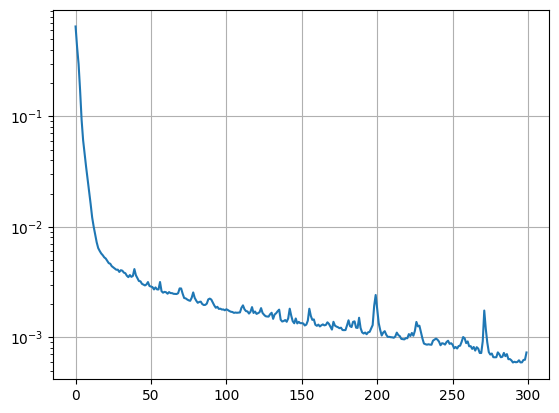

In [79]:
plt.semilogy(loss)
plt.grid()

In [80]:
n = 500
t = np.linspace(t0, tfinal, n)

init_data = np.random.uniform(-np.pi/6, np.pi/6, size=(4,))
z = np.repeat(np.expand_dims(init_data, axis=0), len(t), axis=0)

In [81]:
x1 = jax.vmap(w_model, [0, 0, None, None])(t, z, 0, params)
x2 = jax.vmap(w_model, [0, 0, None, None])(t, z, 1, params)
y1 = jax.vmap(w_model, [0, 0, None, None])(t, z, 2, params)
y2 = jax.vmap(w_model, [0, 0, None, None])(t, z, 3, params)

In [82]:
def doublePendulum(w, t):
    
    x1, x2, y1, y2 = w
    
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)

    x1_t = (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t = (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t = -(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2))
    y2_t = -m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2))

    dwdt = [x1_t, x2_t, y1_t, y2_t]

    return dwdt

sol_rk = odeint(doublePendulum, init_data, t)
x1rk, x2rk, y1rk, y2rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2], sol_rk[:,3]

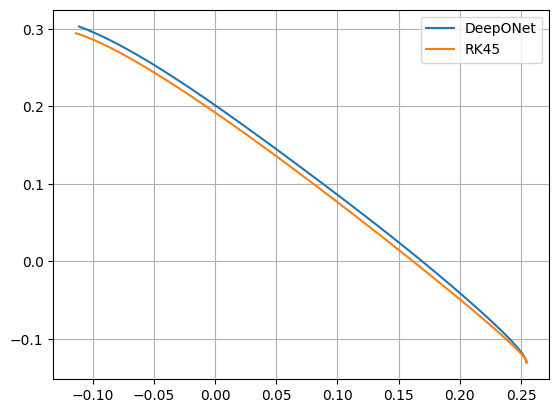

In [83]:
plt.plot(x1, x2)
plt.plot(x1rk, x2rk)

plt.grid()
plt.legend(['DeepONet','RK45'])

Text(0.5, 1.0, 'Solution time series')

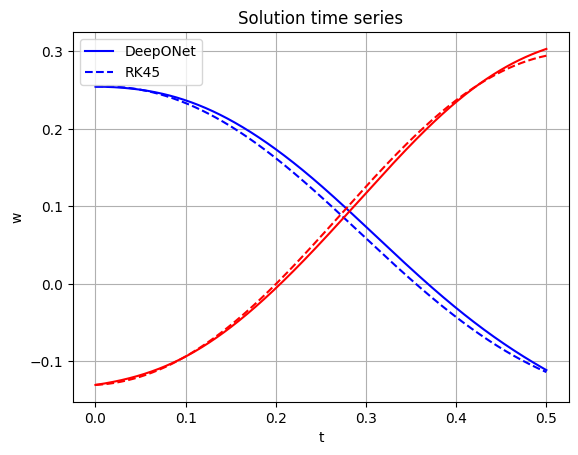

In [84]:
plt.plot(t, x1,'b')
plt.plot(t, x1rk,'b--')

plt.plot(t, x2, 'r')
plt.plot(t, x2rk, 'r--')

plt.legend(['DeepONet', 'RK45'])
plt.grid()
plt.xlabel('t')
plt.ylabel('w')
plt.title('Solution time series')

Text(0.5, 1.0, 'Hamiltonian l2-error: 1.27486')

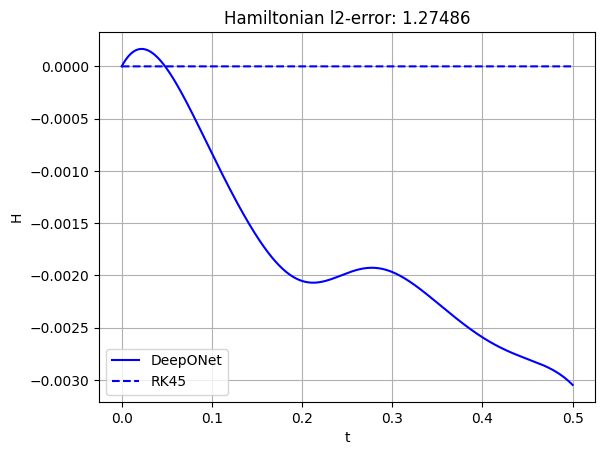

In [85]:
Hs = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*np.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1-x2)**2))-(m1+m2)*grav*l1*np.cos(x1)-m2*grav*l2*np.cos(x2)
H_rk = (m2*l2**2*y1rk**2 + (m1+m2)*l1**2*y2rk**2 - 2*m2*l1*l2*y1rk*y2rk*np.cos(x1rk-x2rk))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1rk-x2rk)**2))-(m1+m2)*grav*l1*np.cos(x1rk)-m2*grav*l2*np.cos(x2rk)

plt.plot(t, (Hs-Hs[0])/Hs[0],'b')
plt.plot(t, (H_rk-H_rk[0])/H_rk[0],'b--')

plt.legend(['DeepONet', 'RK45'])
plt.grid()
plt.xlabel('t')
plt.ylabel('H')
plt.title(f'Hamiltonian l2-error: {np.linalg.norm((Hs-Hs[0])):2.5f}')

In [86]:
H = lambda w: (m2*l2**2*w[:,2]**2 + (m1+m2)*l1**2*w[:,3]**2 - 2*m2*l1*l2*w[:,2]*w[:,3]*jnp.cos(w[:,0]-w[:,1]))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(w[:,0]-w[:,1])**2))-(m1+m2)*grav*l1*jnp.cos(w[:,0])-m2*grav*l2*jnp.cos(w[:,1])
g = lambda w, w0: jnp.expand_dims(H(w) - H(w0), axis=1)

def gp(w):
        
    x1, x2, y1, y2 = w[:,0], w[:,1], w[:,2], w[:,3]
    
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)
    
    d_x1 = (m1 + m2)*grav*l1*jnp.sin(x1) + h1 - h2*jnp.sin(2*(x1 - x2))
    d_x2 = m2*grav*l2*jnp.sin(x2) - h1 + h2*jnp.sin(2*(x1 - x2))
    d_y1 = (l2*y1 - l1*y2*jnp.cos(x1-x2))/(l1*A)
    d_y2 = (l1*(m1+m2)*y2 - m2*l2*y1*jnp.cos(x1-x2))/(m2*l2*A)

    grad = [d_x1, d_x2, d_y1, d_y2]
    
    return jnp.column_stack(grad)

gpgptinv = lambda w: jnp.repeat(jnp.expand_dims(1.0/(jnp.sum(gp(w)**2, axis=1)), axis=1), w.shape[1], axis=1)
dlambda = lambda w, w0, l: -1.0*gpgptinv(w)*g(w + l*gp(w), w0)

In [87]:
class ProjectionLayer(nn.Module):

  @nn.compact
  def __call__(self, inputs):
    z, z0, iterations, avg = inputs
    l = jnp.zeros(z.shape)
    lold = l
    for i in range(iterations):
      if i == iterations-1:
        lold = l
      lupdate = dlambda(z, z0, l)
      l += lupdate
    zc = z + gp(z)*l
    zold = z + gp(z)*lold
    return zc*avg + zold*(1.0-avg)

In [88]:
class cDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, z0, iterations, avg):

    if z0.ndim == 1:
      z0 = jnp.reshape(z0, (1,-1))

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(z0)

    trunk_x1 = trunk_net[:,:self.units]
    trunk_x2 = trunk_net[:,self.units:2*self.units]
    trunk_y1 = trunk_net[:,2*self.units:3*self.units]
    trunk_y2 = trunk_net[:,3*self.units:]

    branch_x1 = branch_net[:,:self.units]
    branch_x2 = branch_net[:,self.units:2*self.units]
    branch_y1 = branch_net[:,2*self.units:3*self.units]
    branch_y2 = branch_net[:,3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, z0[:,:1])([t, x1])
    x2 = HardConstraint(self.t0, self.tfinal, z0[:,1:2])([t, x2])
    y1 = HardConstraint(self.t0, self.tfinal, z0[:,2:3])([t, y1])
    y2 = HardConstraint(self.t0, self.tfinal, z0[:,3:])([t, y2])

    z = jnp.column_stack([x1, x2, y1, y2])

    z = ProjectionLayer()([z, z0, iterations, avg])

    x1 = jnp.reshape(z[:,:1], (-1,))
    x2 = jnp.reshape(z[:,1:2], (-1,))
    y1 = jnp.reshape(z[:,2:3], (-1,))
    y2 = jnp.reshape(z[:,3:], (-1,))

    return x1, x2, y1, y2

In [89]:
cdeeponet = cDeepONet(t0, tfinal, layers=4, units=40)

cparams = cdeeponet.init(jax.random.PRNGKey(0), jnp.ones((10,)), jnp.ones((10,4)),
                         1, 1.0)

# cparams = copy.deepcopy(params)

In [90]:
@partial(jax.jit, static_argnums=(2,3,))
def wc_model(t, z, component, iter, avg, params):
  return cdeeponet.apply(params, t, z, iter, avg)[component][0]

@partial(jax.jit, static_argnums=(2,3,))
def w(t, z, component, iter, avg, params):
  return jax.vmap(wc_model, [0, 0, None, None, None, None])(t, z, component, iter, avg, params)

@partial(jax.jit, static_argnums=(2,3,))
def w_t(t, z, component, iter, avg, params):
  return jax.vmap(jax.grad(wc_model, 0), [0, 0, None, None, None, None])(t, z, component, iter, avg, params)

@partial(jax.jit, static_argnums=(3,))
def loss(params, t, z, iter, avg):

    x1 = w(t, z, 0, iter, avg, params)
    x2 = w(t, z, 1, iter, avg, params)
    y1 = w(t, z, 2, iter, avg, params)
    y2 = w(t, z, 3, iter, avg, params)
    
    x1_t = w_t(t, z, 0, iter, avg, params)
    x2_t = w_t(t, z, 1, iter, avg, params)
    y1_t = w_t(t, z, 2, iter, avg, params)
    y2_t = w_t(t, z, 3, iter, avg, params)
       
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)
    
    x1_t_loss = x1_t - (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t_loss = x2_t - (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t_loss = y1_t - (-(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2)))
    y2_t_loss = y2_t - (-m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2)))

    diff_loss = jnp.mean(x1_t_loss**2 + x2_t_loss**2 + y1_t_loss**2 + y2_t_loss**2)

    return diff_loss

@partial(jax.jit, static_argnums=(3,))
def train_step(params, pdes, z, iter, avg):
  t = pdes[:,0]
  return jax.value_and_grad(loss)(params, t, z, iter, avg)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [91]:
def stepFunction(x, epochs, n):
  iteration = 2*np.floor(x*n/epochs).astype(np.int64)
  return iteration

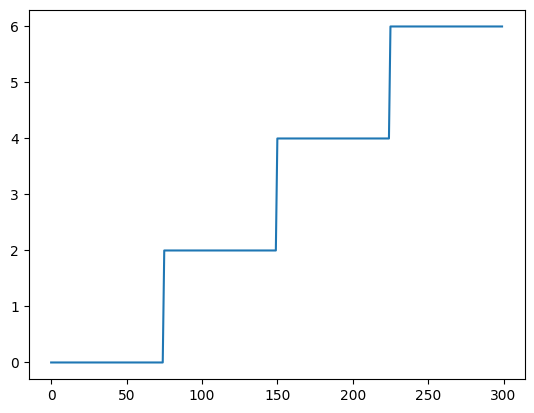

In [92]:
x = np.arange(0,epochs,1)
plt.plot(x, stepFunction(x,epochs,4))

In [93]:
def train_network(params, des, zsensor, epochs=100):

  maxProjection = 4

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(zsensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    iter = stepFunction(i, epochs, maxProjection)
    avg = (i+1)/epochs

    for (des_batch, z_batch) in ds:

      loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy(), iter, avg)
      params, opt_state = optimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 1 == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [94]:
epochs = 300
cparams, loss = train_network(cparams, de_points, zsensors, epochs)

Loss in epoch 0: 0.6489226347032766
Loss in epoch 1: 0.42315184377418086
Loss in epoch 2: 0.30178045427897754
Loss in epoch 3: 0.17562958415025232
Loss in epoch 4: 0.09438930049400998
Loss in epoch 5: 0.06046086537354968
Loss in epoch 6: 0.0444836138421202
Loss in epoch 7: 0.03372268862235355
Loss in epoch 8: 0.026061612837107725
Loss in epoch 9: 0.020041143533960755
Loss in epoch 10: 0.015386475657313704
Loss in epoch 11: 0.012120847139492286
Loss in epoch 12: 0.009714068681561562
Loss in epoch 13: 0.008205213786414261
Loss in epoch 14: 0.007162976982493826
Loss in epoch 15: 0.006495506266986355
Loss in epoch 16: 0.0059742114981467045
Loss in epoch 17: 0.005662022522862968
Loss in epoch 18: 0.0053467699187637035
Loss in epoch 19: 0.005129128524783706
Loss in epoch 20: 0.004949791855598843
Loss in epoch 21: 0.004845298269362182
Loss in epoch 22: 0.004721614273166208
Loss in epoch 23: 0.0045928094683081525
Loss in epoch 24: 0.0044001804816663215
Loss in epoch 25: 0.004352349262634533
Lo

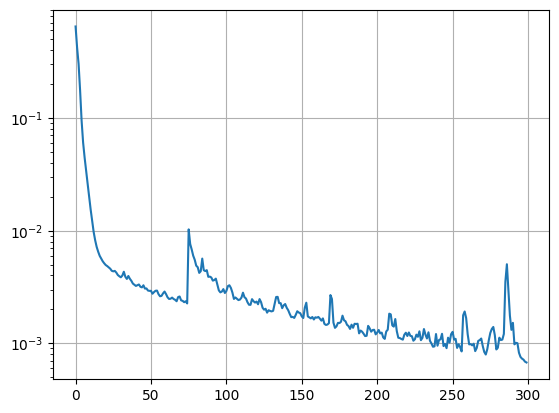

In [95]:
plt.semilogy(loss)
plt.grid()

In [96]:
iters = 100
avg = 1.0

In [97]:
x1c = jax.vmap(wc_model, [0, 0, None, None, None, None])(t, z, 0, iters, avg, cparams)
x2c = jax.vmap(wc_model, [0, 0, None, None, None, None])(t, z, 1, iters, avg, cparams)
y1c = jax.vmap(wc_model, [0, 0, None, None, None, None])(t, z, 2, iters, avg, cparams)
y2c = jax.vmap(wc_model, [0, 0, None, None, None, None])(t, z, 3, iters, avg, cparams)

Text(0.5, 1.0, 'Solution time series')

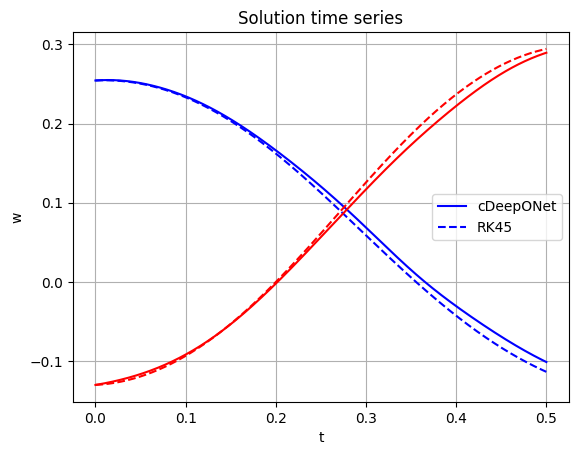

In [98]:
plt.plot(t, x1c,'b')
plt.plot(t, x1rk,'b--')

plt.plot(t, x2c, 'r')
plt.plot(t, x2rk, 'r--')

plt.legend(['cDeepONet', 'RK45'])
plt.grid()
plt.xlabel('t')
plt.ylabel('w')
plt.title('Solution time series')

Text(0.5, 1.0, 'Hamiltonian l2-error: 0.00000')

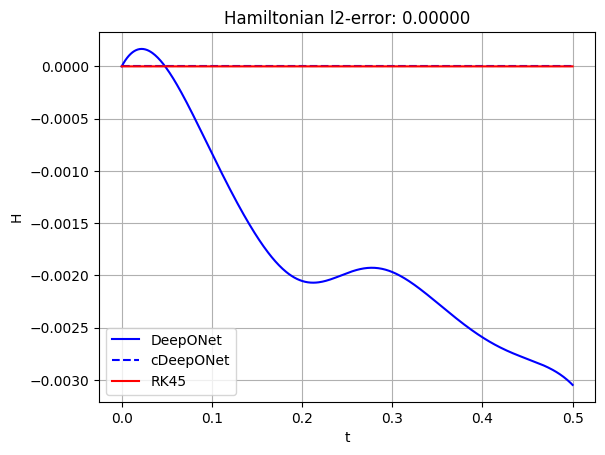

In [99]:
Hc = (m2*l2**2*y1c**2 + (m1+m2)*l1**2*y2c**2 - 2*m2*l1*l2*y1c*y2c*np.cos(x1c-x2c))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1c-x2c)**2))-(m1+m2)*grav*l1*np.cos(x1c)-m2*grav*l2*np.cos(x2c)

plt.plot(t, (Hs-Hs[0])/Hs[0],'b')
plt.plot(t, (Hc-Hc[0])/Hc[0],'b--')
plt.plot(t, (H_rk-H_rk[0])/H_rk[0],'r')

plt.legend(['DeepONet', 'cDeepONet', 'RK45'])
plt.grid()
plt.xlabel('t')
plt.ylabel('H')
plt.title(f'Hamiltonian l2-error: {np.linalg.norm((Hc-Hc[0])):2.5f}')

In [100]:
init_data = np.random.uniform(-np.pi/6, np.pi/6, size=(4,))

In [101]:
print(init_data)

[-0.11432619  0.0217032  -0.02412265  0.49206348]


In [102]:
steps = 20
tfinalsteps = tfinal*steps
tt = np.linspace(0, tfinalsteps, (n-1)*steps)

In [103]:
zinit = init_data

zall = []

for i in range(steps):
  zinit = np.repeat(np.expand_dims(zinit, axis=0), len(t), axis=0)

  x1 = jax.vmap(w_model, [0, 0, None, None])(t, zinit, 0, params)
  x2 = jax.vmap(w_model, [0, 0, None, None])(t, zinit, 1, params)
  y1 = jax.vmap(w_model, [0, 0, None, None])(t, zinit, 2, params)
  y2 = jax.vmap(w_model, [0, 0, None, None])(t, zinit, 3, params)

  zinit = np.array([x1[-1], x2[-1], y1[-1], y2[-1]])
  zall.append(np.column_stack([x1[:-1], x2[:-1], y1[:-1], y2[:-1]]))

zall = np.concatenate(zall, axis=0)

In [104]:
zinit = init_data

zcall = []

for i in range(steps):
  zinit = np.repeat(np.expand_dims(zinit, axis=0), len(t), axis=0)

  x1 = jax.vmap(wc_model, [0, 0, None, None, None, None])(t, zinit, 0, iters, avg, cparams)
  x2 = jax.vmap(wc_model, [0, 0, None, None, None, None])(t, zinit, 1, iters, avg, cparams)
  y1 = jax.vmap(wc_model, [0, 0, None, None, None, None])(t, zinit, 2, iters, avg, cparams)
  y2 = jax.vmap(wc_model, [0, 0, None, None, None, None])(t, zinit, 3, iters, avg, cparams)

  zinit = np.array([x1[-1], x2[-1], y1[-1], y2[-1]])
  zcall.append(np.column_stack([x1[:-1], x2[:-1], y1[:-1], y2[:-1]]))

zcall = np.concatenate(zcall, axis=0)

In [105]:
zrkall = odeint(doublePendulum, init_data, tt)

In [106]:
print(zrkall.shape, zcall.shape)

(9980, 4) (9980, 4)


Text(0, 0.5, '$q_2$')

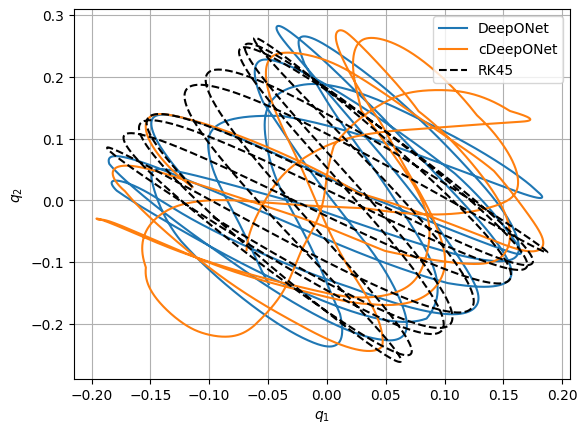

In [107]:
plt.plot(zall[:,0], zall[:,1])
plt.plot(zcall[:,0], zcall[:,1])
plt.plot(zrkall[:,0], zrkall[:,1],'k--')
plt.legend(['DeepONet', 'cDeepONet', 'RK45'])
plt.grid()
plt.xlabel('$q_1$')
plt.ylabel('$q_2$')

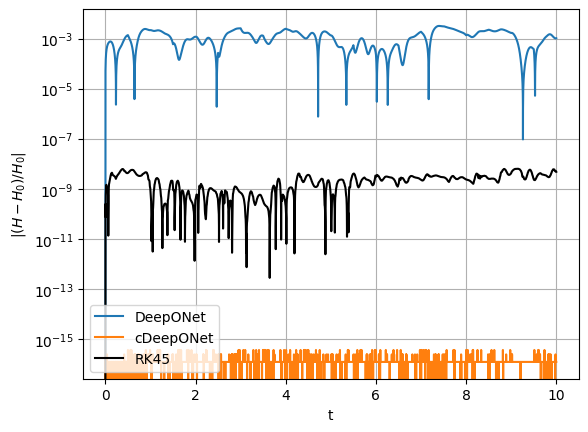

In [108]:
x1, x2, y1, y2 = zall[:,0], zall[:,1], zall[:,2], zall[:,3]
x1c, x2c, y1c, y2c = zcall[:,0], zcall[:,1], zcall[:,2], zcall[:,3]
x1rk, x2rk, y1rk, y2rk = zrkall[:,0], zrkall[:,1], zrkall[:,2], zrkall[:,3]

Hs = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*np.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1-x2)**2))-(m1+m2)*grav*l1*np.cos(x1)-m2*grav*l2*np.cos(x2)
Hc = (m2*l2**2*y1c**2 + (m1+m2)*l1**2*y2c**2 - 2*m2*l1*l2*y1c*y2c*np.cos(x1c-x2c))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1c-x2c)**2))-(m1+m2)*grav*l1*np.cos(x1c)-m2*grav*l2*np.cos(x2c)
H_rk = (m2*l2**2*y1rk**2 + (m1+m2)*l1**2*y2rk**2 - 2*m2*l1*l2*y1rk*y2rk*np.cos(x1rk-x2rk))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1rk-x2rk)**2))-(m1+m2)*grav*l1*np.cos(x1rk)-m2*grav*l2*np.cos(x2rk)

plt.semilogy(tt, np.abs((Hs-Hs[0])/Hs[0]))
plt.semilogy(tt, np.abs((Hc-Hc[0])/Hc[0]))
plt.semilogy(tt, np.abs((H_rk-H_rk[0])/H_rk[0]),'k')
plt.legend(['DeepONet', 'cDeepONet', 'RK45'])
plt.grid()
plt.xlabel('t')
plt.ylabel('$|(H-H_0)/H_0|$')
plt.show()